In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## Building and Analysing an Ensemble Classifier for Heart Disease Prediction

### Context & Goal

You are a data scientist for a healthcare research institute investigating predictive systems for cardiovascular risk assessment. Your objective is to build and critically evaluate an **ensemble of classifiers** that collectively determine whether a patient is likely to develop heart disease.

You will:

1. Design and justify the inclusion of heterogeneous base models.
2. Evaluate each base model’s standalone accuracy.
3. Combine them through **majority voting**.
4. Analyse bias, variance, and complementarity among the models.

### Dataset

**Name:** Heart Disease Dataset (Cleveland subset)
**Source:** [UCI Heart Disease Repository](https://archive.ics.uci.edu/ml/datasets/heart+Disease)

**Features (selected examples):**

* `age`, `sex`, `cp` (chest pain type) <br>
* `trestbps` (resting blood pressure) <br>
* `chol` (serum cholesterol) <br>
* `thalach` (maximum heart rate achieved) <br>
* `oldpeak` (ST depression induced by exercise) <br>
* `ca`, `thal` (angiographic data) <br>

**Target:**
`target` (binary — 1 indicates presence of heart disease, 0 otherwise).


### Phase 1 – Preprocessing & Design Decisions

1. Load the dataset from an online repository or local file.
2. Handle missing data (e.g. impute with median or drop rows).
3. Normalise or standardise numeric features (especially for KNN and Logistic Regression).
4. Split the data into **training (70%)** and **testing (30%)** sets with a fixed random state.
5. Clearly justify your preprocessing strategy — different classifiers have different assumptions (e.g. KNN is sensitive to scaling).

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
heart_disease = fetch_ucirepo(id=45)

# data (as pandas dataframes)
X = heart_disease.data.features
y = heart_disease.data.targets

In [ ]:
# Check the original target distribution
print("Original target distribution:")
print(y.value_counts().sort_index())
print(f"\nUnique values: {sorted(y['num'].unique())}")

Original target distribution:
num
0      164
1       55
2       36
3       35
4       13
Name: count, dtype: int64

Unique values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [ ]:
# Convert to binary classification: 0 = no disease, 1 = disease present (any level)
# Original: 0 = no disease, 1-4 = different levels of disease
y_binary = (y["num"] > 0).astype(int)

# Replace y with the binary version
y = pd.DataFrame(y_binary, columns=["num"])

print("\nBinary target distribution:")
print(y.value_counts().sort_index())


Binary target distribution:
num
0      164
1      139
Name: count, dtype: int64


In [ ]:
meta = heart_disease.metadata

meta_df = pd.DataFrame(
	data=[(k, v) for k, v in meta.items() if v is not None],
	columns=["Attribute", "Value"],
)
display(meta_df)

,Attribute,Value
0,uci_id,45
1,name,Heart Disease
2,repository_url,https://archive.ics.uci.edu/dataset/45/heart+d...
3,data_url,https://archive.ics.uci.edu/static/public/45/d...
4,abstract,"4 databases: Cleveland, Hungary, Switzerland, ..."
5,area,Health and Medicine
6,tasks,[Classification]
7,characteristics,[Multivariate]
8,num_instances,303
9,num_features,13


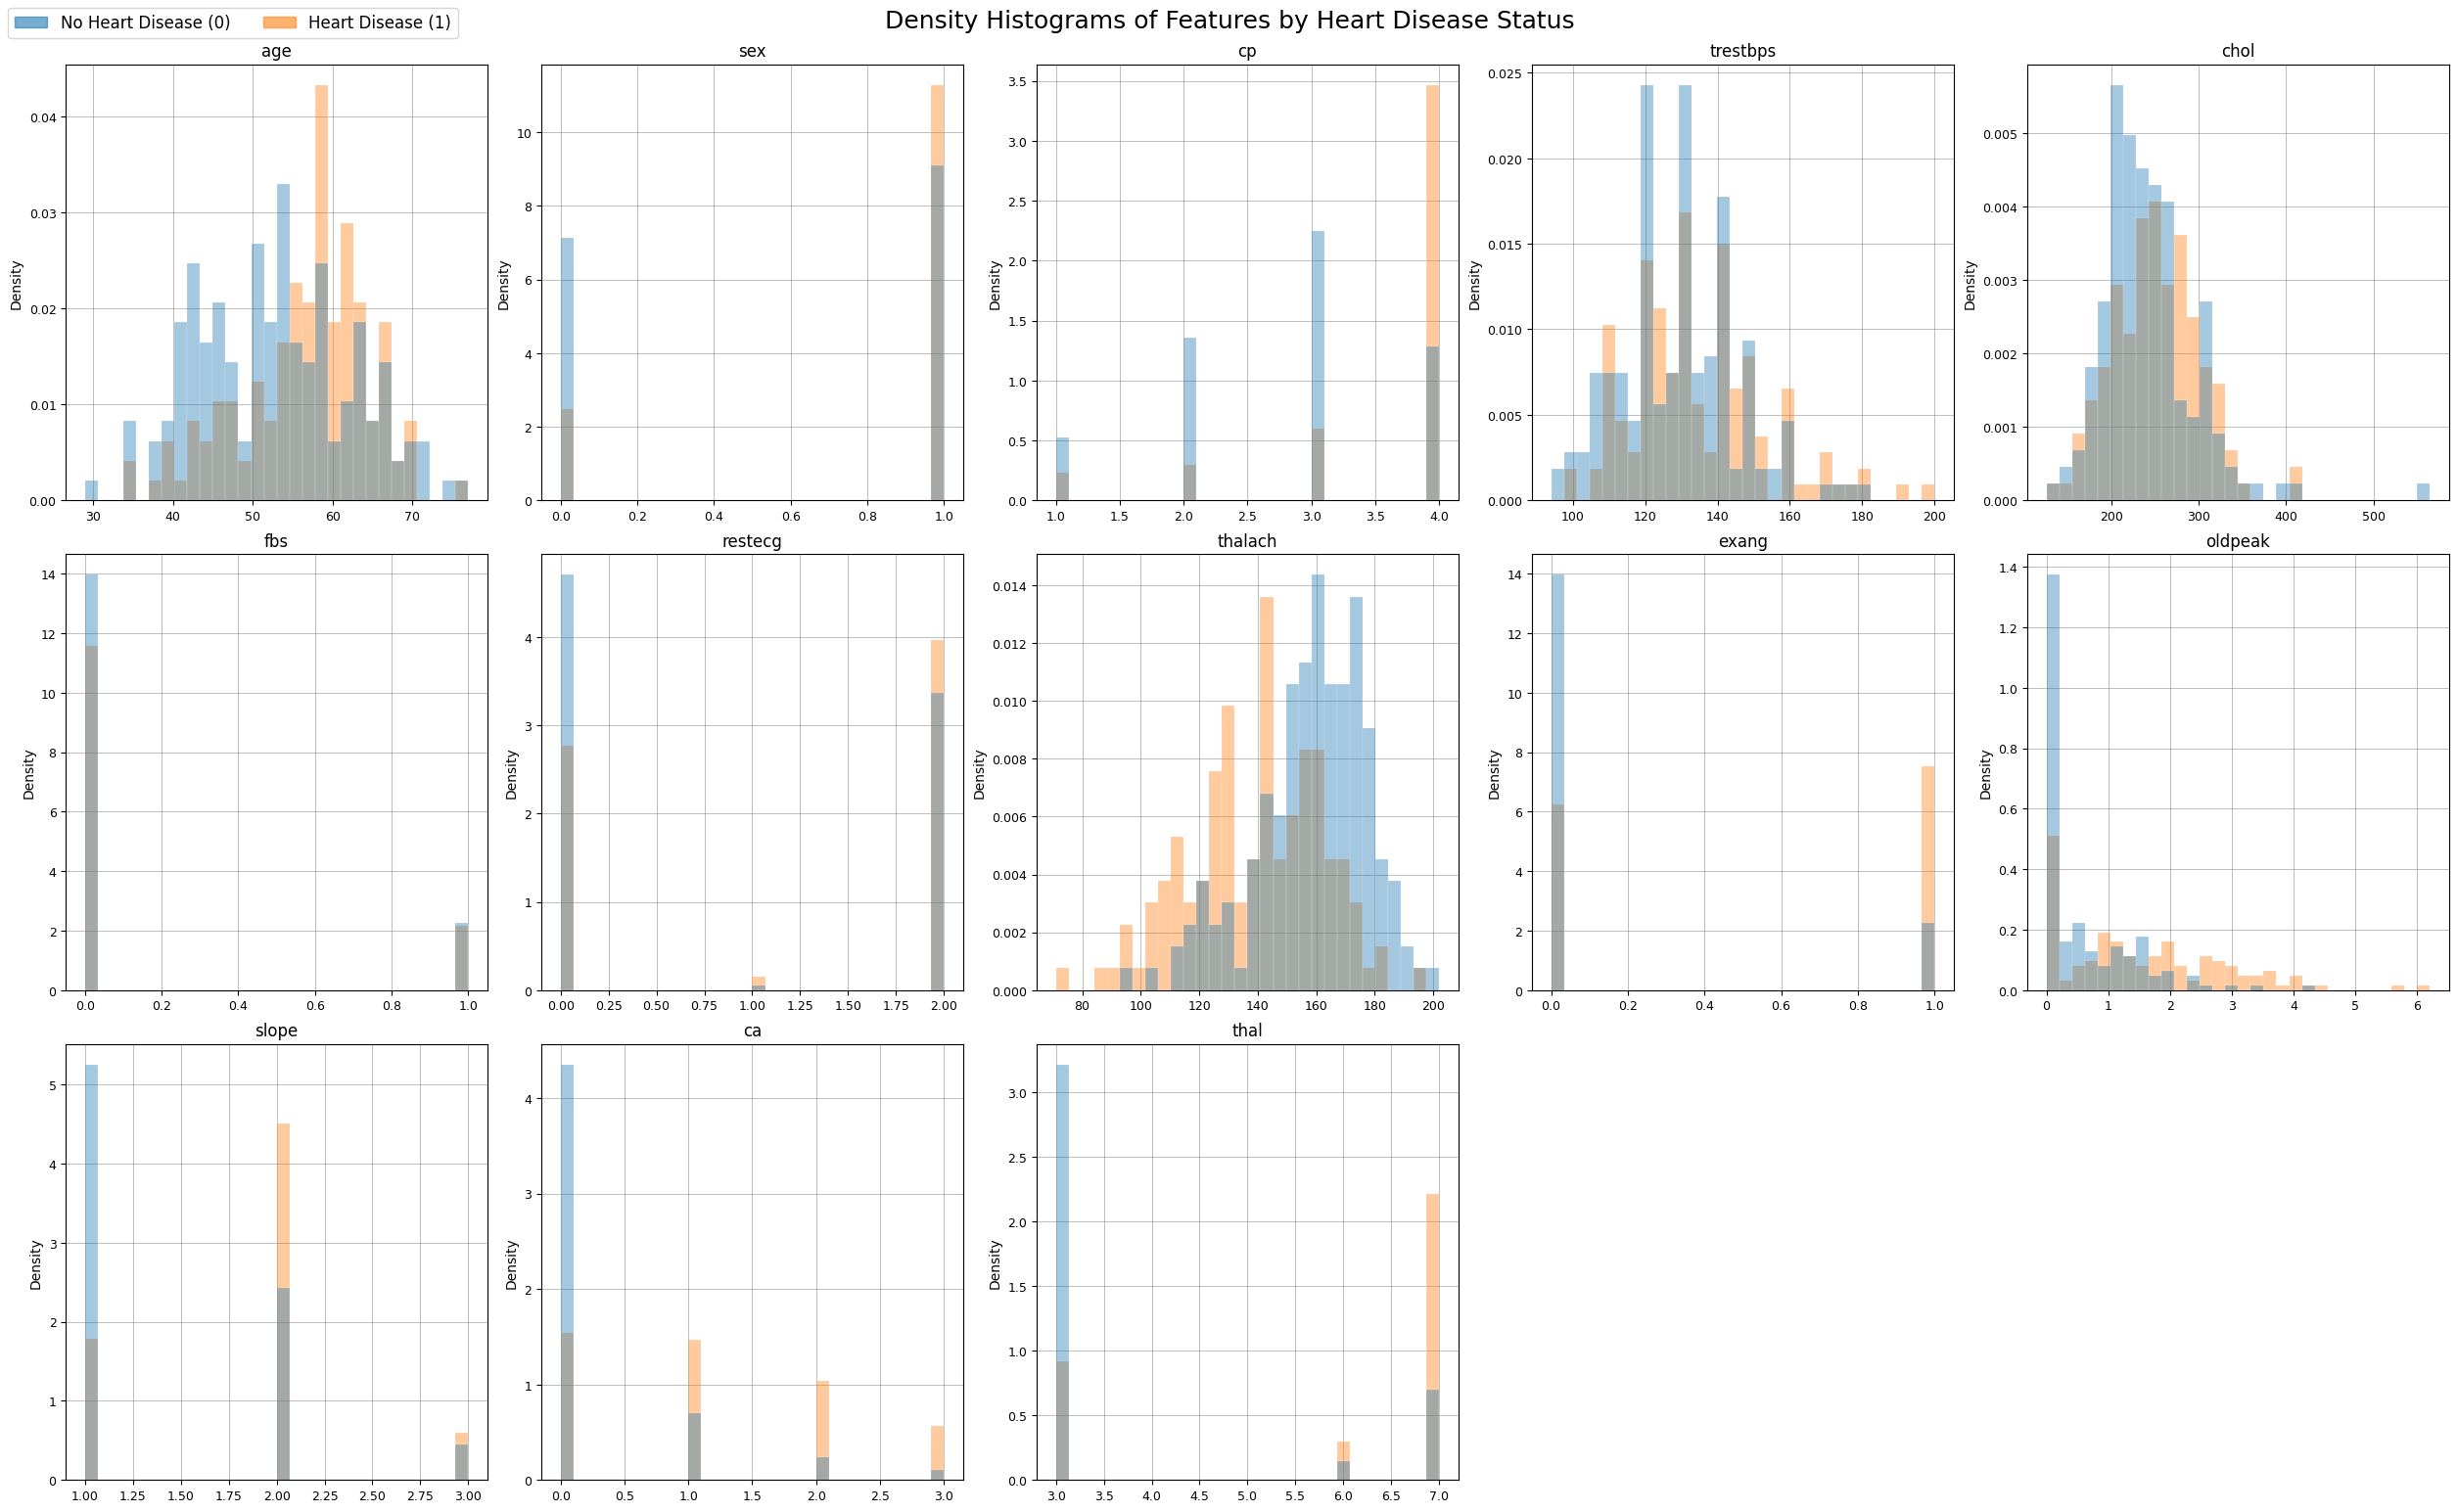

In [ ]:
# Combine features with target for plotting
df_plot = X.copy()
df_plot["target"] = y

feature_names = X.columns
num_features = len(feature_names)

# Adjust subplot layout for 13 features (3 rows x 5 columns = 15 subplots)
fig, axes = plt.subplots(3, 5, figsize=(25, 15), constrained_layout=True)
axes = axes.ravel()

for axis, feature in zip(axes, feature_names):
	sns.histplot(
		data=df_plot,
		x=feature,
		hue="target",
		hue_order=[0, 1],  # Binary classification: 0 = no disease, 1 = disease
		stat="density",
		bins=30,
		alpha=0.4,
		edgecolor="white",
		linewidth=0.1,
		ax=axis,
		legend=False,
		palette=["#1f77b4", "#ff7f0e"],  # Use darker, more visible colors
	)
	axis.set_title(feature, fontsize=12)
	axis.set_xlabel("")
	axis.set_ylabel("Density", fontsize=10)
	axis.tick_params(axis="both", labelsize=9)
	axis.grid(True, alpha=0.6, linewidth=0.6, color="grey")
	axis.set_axisbelow(True)

# Hide unused subplots (we have 13 features but 15 subplots)
for i in range(num_features, len(axes)):
	axes[i].set_visible(False)

# Single, consistent legend positioned outside the plots
handles = [
	plt.Rectangle((0, 0), 1, 1, color="#1f77b4", alpha=0.6),  # Updated colors to match
	plt.Rectangle((0, 0), 1, 1, color="#ff7f0e", alpha=0.6),  # Updated colors to match
]
fig.legend(
	handles,
	["No Heart Disease (0)", "Heart Disease (1)"],
	loc="upper left",
	ncol=2,
	frameon=True,
	fontsize=12,
)

# Overall figure adjustments for readability
fig.suptitle(
	"Density Histograms of Features by Heart Disease Status", fontsize=18, y=1.02
)
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)

### Phase 2 – Individual Models

Build and train three conceptually distinct models:

1. **Logistic Regression (`lr`)**

   * Baseline linear classifier.
   * Tune regularisation strength (`C`) and penalty type (`l2` preferred).

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline with scaling and logistic regression
pipeline = Pipeline([
	("scaler", StandardScaler()),
	("lr", LogisticRegression(random_state=42, max_iter=1000)),
])

# Define the parameter grid with solver-penalty combinations
param_grid = [
	# lbfgs with l2 and None
	{
		"lr__solver": ["lbfgs"],
		"lr__penalty": ["l2", None],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
	# liblinear with l1 and l2
	{
		"lr__solver": ["liblinear"],
		"lr__penalty": ["l1", "l2"],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
	# saga with l1, l2, elasticnet, and None
	{
		"lr__solver": ["saga"],
		"lr__penalty": ["l1", "l2", None],
		"lr__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
	},
]

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

# Fit on the training data
grid_search.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
lr = grid_search.best_estimator_

# Print the best parameters and score
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'lr__C': 1, 'lr__penalty': 'l1', 'lr__solver': 'liblinear'}
Best cross-validation accuracy: 0.8345


2. **K-Nearest Neighbours (`knn`)**

   * Non-parametric, instance-based model.
   * Choose a meaningful value of `n_neighbors` (e.g. 25–35) and justify your reasoning (trade-off between bias and variance).

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Create a pipeline with scaling and KNN
# Scaling is crucial for KNN as it's distance-based
pipeline = Pipeline([
	("scaler", StandardScaler()),
	("knn", KNeighborsClassifier()),
])

# Define the parameter grid for n_neighbors
# Testing values from 25-35 as suggested, plus some surrounding values
param_grid = {
	"knn__n_neighbors": [11, 15, 21, 25, 27, 31, 33, 35],
	"knn__weights": ["uniform", "distance"],
	"knn__metric": ["minkowski"],
	"knn__p": [1, 2],
	"knn__algorithm": ["auto"],
	"knn__leaf_size": [20, 30, 40],
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring="accuracy", n_jobs=-1)

# Fit on the training data (using imputed data)
grid_search.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
knn = grid_search.best_estimator_

# Print the best parameters and score
print(f"Best n_neighbors parameter: {grid_search.best_params_['knn__n_neighbors']}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best n_neighbors parameter: 11
Best cross-validation accuracy: 0.8429


3. **Decision Tree (`dt`)**

   * High-variance, rule-based learner.
   * Set a moderate `max_depth` and a small but non-zero `min_samples_leaf` to avoid overfitting.

Document the intuition for including each model — the ensemble only works if the base learners make *different kinds of errors*.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeClassifier

param_grid_tree = {
	"criterion": ["gini", "entropy"],
	"max_depth": [None, 3, 5, 8, 12, 16],
	"min_samples_split": [2, 5, 10, 20],
	"min_samples_leaf": [1, 2, 5, 10, 20],
	"max_features": [None, "sqrt", "log2"],
	"class_weight": [None, "balanced"],
}

grid_tree = GridSearchCV(
	estimator=DecisionTreeClassifier(random_state=42),
	param_grid=param_grid_tree,
	cv=5,
	scoring="accuracy",
	n_jobs=-1,
	verbose=0,
	refit=True,
	return_train_score=True,
	error_score="raise",
)

grid_tree.fit(X_train_imputed, y_train.values.ravel())

dt = grid_tree.best_estimator_

print(f"Best parameters: {grid_tree.best_params_}")
print(f"Best cross-validation accuracy: {grid_tree.best_score_:.4f}")

Best parameters: {'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best cross-validation accuracy: 0.7723


### Phase 3 – Model Evaluation

1. Train each classifier on the training data.
2. Evaluate on the test set using **accuracy**, **precision**, **recall**, and **F1-score**.
3. Compare the confusion matrices of all models to analyse error distribution.
4. Briefly discuss which models complement each other (e.g. tree capturing non-linearities missed by logistic regression).

In [ ]:
from sklearn.metrics import classification_report

lr.fit(X_train_imputed, y_train.values.ravel())
y_pred = lr.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [ ]:
from sklearn.metrics import classification_report

knn.fit(X_train_imputed, y_train.values.ravel())
y_pred = knn.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.82      0.89        33
           1       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



In [ ]:
from sklearn.metrics import classification_report

dt.fit(X_train_imputed, y_train.values.ravel())
y_pred = dt.predict(X_test_imputed)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.64      0.71        33
           1       0.66      0.82      0.73        28

    accuracy                           0.72        61
   macro avg       0.73      0.73      0.72        61
weighted avg       0.74      0.72      0.72        61



### Phase 4 – Ensemble Construction

1. Combine the trained classifiers using `VotingClassifier` from `sklearn.ensemble`.
2. Implement both strategies:

   * **Hard Voting:** majority class vote.
   * **Soft Voting:** average predicted probabilities (requires classifiers that support `predict_proba`).
3. Evaluate ensemble performance using the same metrics as above.
4. Compare to the individual base models quantitatively and qualitatively.

> **Hard Voting**

In [75]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report

# Store estimators as (name, classifier) tuples for VotingClassifier
estimators = [
	("Logistic Regression", lr),
	("Decision Tree", dt),
	("K-Nearest Neighbors", knn),
]

# Create a VotingClassifier with soft voting (required for predict_proba)
voting_clf_hard = VotingClassifier(estimators=estimators, voting="hard")

# Define parameter grid for the VotingClassifier
# We can tune weights for each classifier to give more importance to better performers
param_grid_hard = {
	"weights": [
		[1, 1, 1],  # Equal weights
		[2, 1, 1],  # More weight to Logistic Regression
		[1, 2, 1],  # More weight to Decision Tree
		[1, 1, 2],  # More weight to KNN
		[3, 1, 1],  # Even more weight to Logistic Regression
		[2, 2, 1],  # More weight to LR and DT
		[2, 1, 2],  # More weight to LR and KNN
		[1, 2, 2],  # More weight to DT and KNN
	]
}

# Perform grid search with cross-validation
grid_search_hard = GridSearchCV(
	voting_clf_hard, param_grid_hard, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)

# Fit on the training data
grid_search_hard.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
voting_clf_hard = grid_search_hard.best_estimator_

# Print the best parameters and score
print(f"Best weights: {grid_search_hard.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_hard.best_score_:.4f}")

# Evaluate on test set
y_pred_best = voting_clf_hard.predict(X_test_imputed)
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_best))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best weights: {'weights': [1, 1, 2]}
Best cross-validation accuracy: 0.8470

Test Set Performance:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88        33
           1       0.83      0.89      0.86        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



> **Soft Voting**

In [74]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import GridSearchCV

# Store estimators as (name, classifier) tuples for VotingClassifier
estimators = [
	("Logistic Regression", lr),
	("Decision Tree", dt),
	("K-Nearest Neighbors", knn),
]

# Create a VotingClassifier with soft voting
voting_clf_soft = VotingClassifier(estimators=estimators, voting="soft")

# Define parameter grid for soft voting weights
param_grid_soft = {
	"weights": [
		[1, 1, 1],  # Equal weights
		[2, 1, 1],  # More weight to Logistic Regression
		[1, 2, 1],  # More weight to Decision Tree
		[1, 1, 2],  # More weight to KNN
		[3, 1, 1],  # Even more weight to Logistic Regression
		[2, 2, 1],  # More weight to LR and DT
		[2, 1, 2],  # More weight to LR and KNN
		[1, 2, 2],  # More weight to DT and KNN
	]
}

# Perform grid search with cross-validation
grid_search_soft = GridSearchCV(
	voting_clf_soft, param_grid_soft, cv=5, scoring="accuracy", n_jobs=-1, verbose=1
)

# Fit on the training data
grid_search_soft.fit(X_train_imputed, y_train.values.ravel())

# Get the best model
voting_clf_soft = grid_search_soft.best_estimator_

# Print the best parameters and score
print(f"Best weights: {grid_search_soft.best_params_}")
print(f"Best cross-validation accuracy: {grid_search_soft.best_score_:.4f}")

# Evaluate on test set
y_pred_sft = voting_clf_soft.predict(X_test_imputed)
print("\nTest Set Performance:")
print(classification_report(y_test, y_pred_sft))


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best weights: {'weights': [3, 1, 1]}
Best cross-validation accuracy: 0.8345

Test Set Performance:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



### Phase 5 – Analytical Discussion

* If the ensemble outperforms all individual models, explain which component models contributed to that gain.
* If not, diagnose why — e.g. correlated errors, unbalanced votes, poor calibration.
* Reflect on bias–variance interplay across the three base models.
* Optionally, compute ROC-AUC and visualise the ROC curves for individual and ensemble models.

In [76]:
# Get predictions and probabilities for all models
models = {
	"Logistic Regression": lr,
	"Decision Tree": dt,
	"K-Nearest Neighbors": knn,
	"Hard Voting": voting_clf_hard,
	"Soft Voting": voting_clf_soft,
}

In [77]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

In [ ]:
# 1. ROC-AUC ANALYSIS
print("=" * 60)
print("ROC-AUC SCORES AND PERFORMANCE METRICS")
print("=" * 60)

roc_data = {}
for name, model in models.items():
	if hasattr(model, "predict_proba"):
		y_proba = model.predict_proba(X_test_imputed)[:, 1]
		auc = roc_auc_score(y_test, y_proba)
		fpr, tpr, thresholds = roc_curve(y_test, y_proba)
		roc_data[name] = {"fpr": fpr, "tpr": tpr, "auc": auc}
		print(f"{name:25s}: AUC = {auc:.4f}")
	else:
		print(f"{name:25s}: N/A (no predict_proba method)")

ROC-AUC SCORES AND PERFORMANCE METRICS
Logistic Regression      : AUC = 0.9448
Decision Tree            : AUC = 0.8550
K-Nearest Neighbors      : AUC = 0.9610
Hard Voting              : N/A (no predict_proba method)
Soft Voting              : AUC = 0.9459


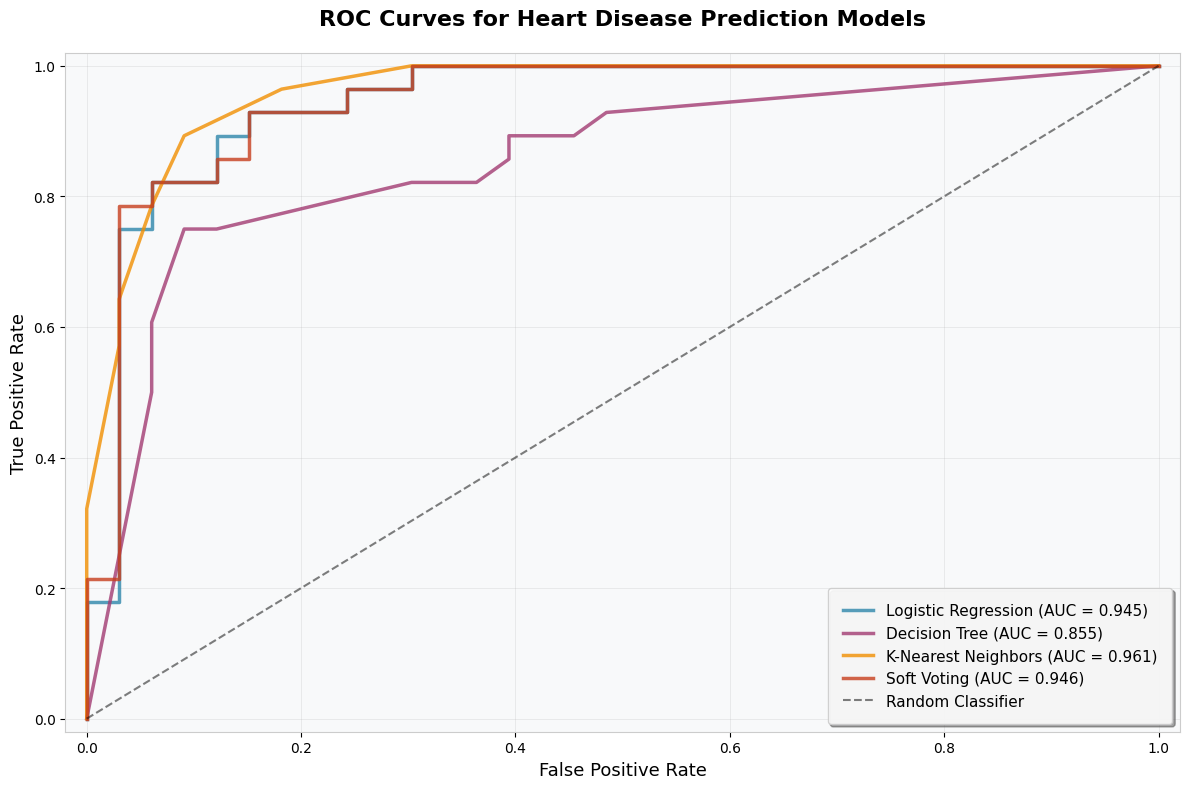

In [80]:
# Plot ROC Curves
fig, ax = plt.subplots(figsize=(12, 8))

# Use softer, more professional colors
colors = ["#2E86AB", "#A23B72", "#F18F01", "#C73E1D", "#6B4C7A"]

for (name, data), color in zip(roc_data.items(), colors):
	ax.plot(
		data["fpr"],
		data["tpr"],
		color=color,
		lw=2.5,
		alpha=0.8,
		label=f"{name} (AUC = {data['auc']:.3f})",
	)

# Add diagonal reference line with subtle styling
ax.plot([0, 1], [0, 1], "k--", lw=1.5, alpha=0.5, label="Random Classifier")

# Styling improvements
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.02])
ax.set_xlabel("False Positive Rate", fontsize=13, fontweight="500")
ax.set_ylabel("True Positive Rate", fontsize=13, fontweight="500")
ax.set_title(
	"ROC Curves for Heart Disease Prediction Models",
	fontsize=16,
	fontweight="bold",
	pad=20,
)

# Improve legend
ax.legend(
	loc="lower right",
	fontsize=11,
	framealpha=0.9,
	fancybox=True,
	shadow=True,
	borderpad=1,
)

# Add subtle grid
ax.grid(True, alpha=0.3, linestyle="-", linewidth=0.5)
ax.set_axisbelow(True)

# Set background color
ax.set_facecolor("#f8f9fa")

# Add subtle border
for spine in ax.spines.values():
	spine.set_edgecolor("#cccccc")
	spine.set_linewidth(0.8)

plt.tight_layout()
plt.show()


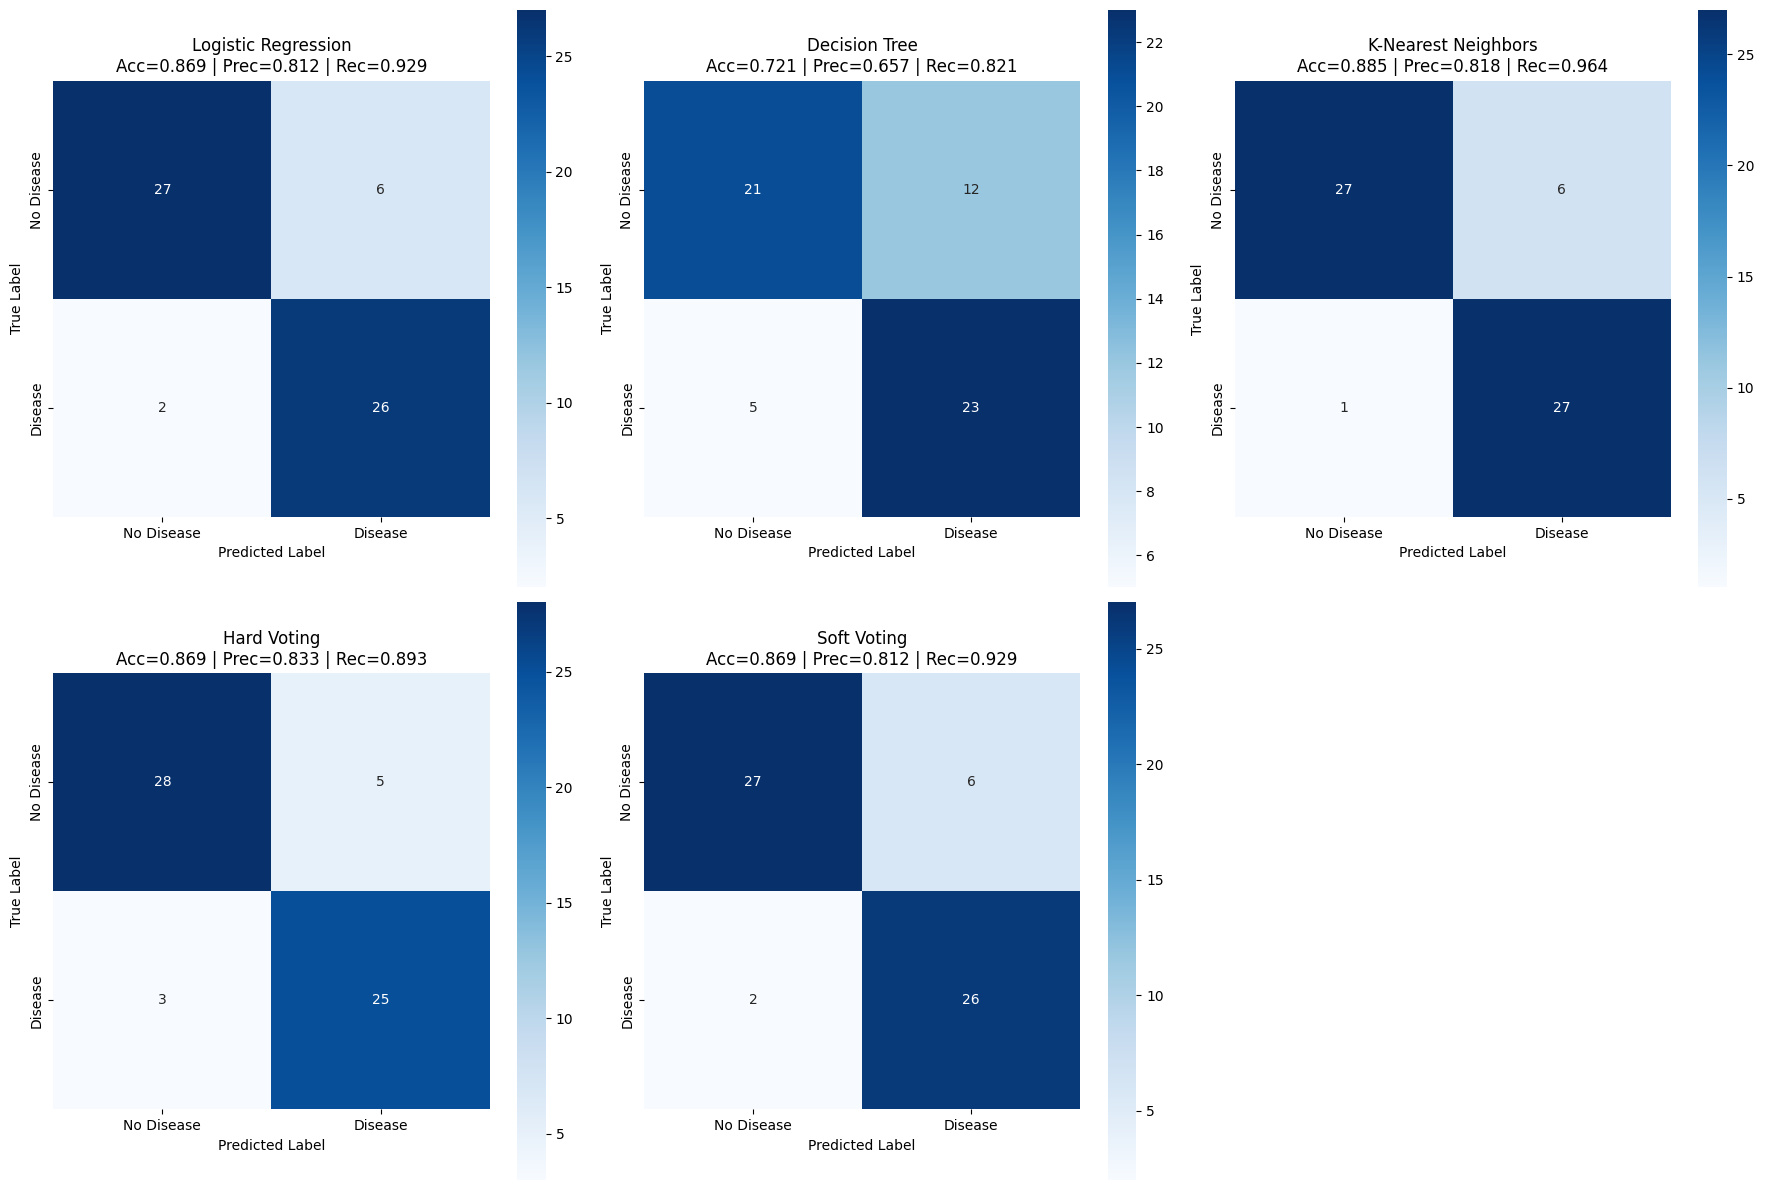

In [81]:
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for idx, (name, model) in enumerate(models.items()):
	y_pred = model.predict(X_test_imputed)
	cm = confusion_matrix(y_test, y_pred)

	# Calculate metrics from confusion matrix
	tn, fp, fn, tp = cm.ravel()
	accuracy = (tp + tn) / (tp + tn + fp + fn)
	precision = tp / (tp + fp) if (tp + fp) > 0 else 0
	recall = tp / (tp + fn) if (tp + fn) > 0 else 0
	specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

	# Plot confusion matrix using seaborn
	sns.heatmap(
		cm,
		annot=True,
		fmt="d",
		cmap="Blues",
		square=True,
		cbar=True,
		ax=axes[idx],
		xticklabels=["No Disease", "Disease"],
		yticklabels=["No Disease", "Disease"],
	)

	axes[idx].set(
		title=f"{name}\nAcc={accuracy:.3f} | Prec={precision:.3f} | Rec={recall:.3f}",
		ylabel="True Label",
		xlabel="Predicted Label",
	)

# Hide the last subplot if not used
axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [82]:
# 3. ERROR CORRELATION ANALYSIS
print("\n" + "=" * 80)
print("MODEL COMPLEMENTARITY ANALYSIS")
print("=" * 80)

# Get predictions from all base models
lr_pred = lr.predict(X_test_imputed)
dt_pred = dt.predict(X_test_imputed)
knn_pred = knn.predict(X_test_imputed)

# Calculate error indicators
errors = {
	"LR": lr_pred != y_test.values.ravel(),
	"DT": dt_pred != y_test.values.ravel(),
	"KNN": knn_pred != y_test.values.ravel(),
}

# Error correlation matrix
print("\nError Correlation Matrix:")
print("(High values indicate models make similar mistakes)")
error_corr = pd.DataFrame(errors).corr()
print(error_corr.round(3))


MODEL COMPLEMENTARITY ANALYSIS

Error Correlation Matrix:
(High values indicate models make similar mistakes)
        LR     DT    KNN
LR   1.000  0.408  0.622
DT   0.408  1.000  0.120
KNN  0.622  0.120  1.000


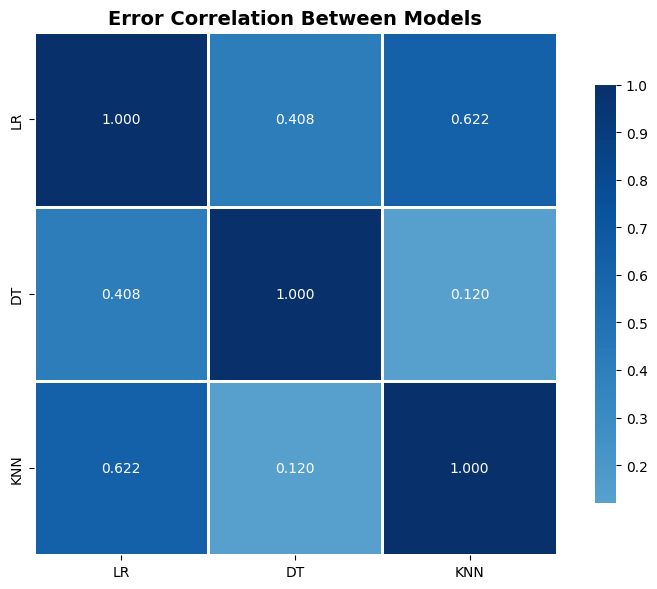

In [83]:
# Visualize error correlation
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
	error_corr,
	annot=True,
	fmt=".3f",
	cmap="Blues",
	center=0,
	square=True,
	linewidths=1,
	cbar_kws={"shrink": 0.8},
	ax=ax,
)
ax.set_title("Error Correlation Between Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [84]:
# 4. MODEL DISAGREEMENT ANALYSIS
disagreements = 0
agreement_patterns = {
	"All Correct": 0,
	"All Wrong": 0,
	"2 Correct": 0,
	"1 Correct": 0,
}

y_true_ravel = y_test.values.ravel()

for i in range(len(y_test)):
	predictions = [lr_pred[i], dt_pred[i], knn_pred[i]]
	correct = [pred == y_true_ravel[i] for pred in predictions]
	num_correct = sum(correct)

	if len(set(predictions)) > 1:  # Models disagree
		disagreements += 1

	if num_correct == 3:
		agreement_patterns["All Correct"] += 1
	elif num_correct == 0:
		agreement_patterns["All Wrong"] += 1
	elif num_correct == 2:
		agreement_patterns["2 Correct"] += 1
	else:
		agreement_patterns["1 Correct"] += 1

print(
	f"\nModels disagree on {disagreements}/{len(y_test)} instances ({disagreements / len(y_test) * 100:.1f}%)"
)
print("\nAgreement Pattern Distribution:")
for pattern, count in agreement_patterns.items():
	print(f"  {pattern:15s}: {count:3d} instances ({count / len(y_test) * 100:.1f}%)")


Models disagree on 18/61 instances (29.5%)

Agreement Pattern Distribution:
  All Correct    :  40 instances (65.6%)
  All Wrong      :   3 instances (4.9%)
  2 Correct      :  13 instances (21.3%)
  1 Correct      :   5 instances (8.2%)


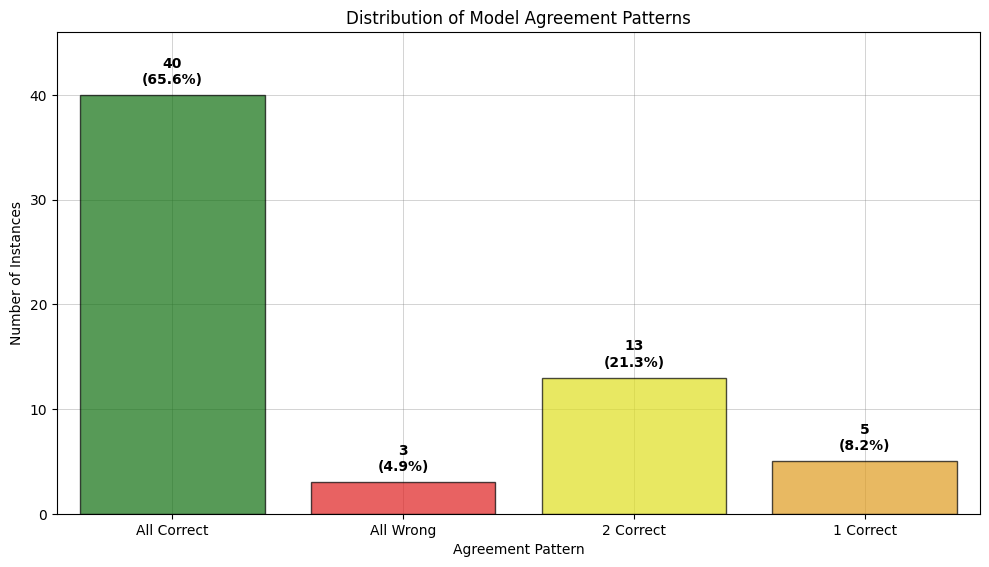

In [85]:
# Visualize agreement patterns using Seaborn
fig, ax = plt.subplots(figsize=(10, 6))
patterns = list(agreement_patterns.keys())
counts = list(agreement_patterns.values())
colors = ["green", "red", "yellow", "orange"]
sns.barplot(
	x=patterns,
	y=counts,
	ax=ax,
	hue=patterns,
	palette=colors,
	alpha=0.7,
	edgecolor="black",
	legend=False,
)

ax.set(
	title="Distribution of Model Agreement Patterns",
	xlabel="Agreement Pattern",
	ylabel="Number of Instances",
)
ax.grid(True, alpha=0.6, linewidth=0.4, color="grey")
ax.set_axisbelow(True)

# Adjust y-axis limit to make space for annotations
max_count = max(counts)
ax.set_ylim(0, max_count + max_count * 0.15)

for i, (pattern, count) in enumerate(zip(patterns, counts)):
	ax.text(
		i,
		count + max_count * 0.02,  # Position text slightly above bar
		f"{count}\n({count / len(y_test) * 100:.1f}%)",
		ha="center",
		va="bottom",
		fontsize=10,
		weight="bold",
	)

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

In [86]:
# 5. DETAILED ENSEMBLE ANALYSIS
hard_pred = voting_clf_hard.predict(X_test_imputed)
soft_pred = voting_clf_soft.predict(X_test_imputed)

# Compare ensemble predictions
ensemble_diff = np.sum(hard_pred != soft_pred)
print(
	f"\nHard vs Soft Voting differences: {ensemble_diff}/{len(y_test)} instances ({ensemble_diff / len(y_test) * 100:.1f}%)"
)

# Analyze cases where ensembles differ
if ensemble_diff > 0:
	print("\nCases where Hard and Soft Voting disagree:")
	diff_indices = np.where(hard_pred != soft_pred)[0]
	for idx in diff_indices[:5]:  # Show first 5 cases
		print(
			f"  Instance {idx}: LR={lr_pred[idx]}, DT={dt_pred[idx]}, KNN={knn_pred[idx]} | "
			f"Hard={hard_pred[idx]}, Soft={soft_pred[idx]}, True={y_true_ravel[idx]}"
		)



Hard vs Soft Voting differences: 2/61 instances (3.3%)

Cases where Hard and Soft Voting disagree:
  Instance 52: LR=1, DT=1, KNN=0 | Hard=0, Soft=1, True=0
  Instance 57: LR=1, DT=1, KNN=0 | Hard=0, Soft=1, True=1


### Bias-Variance Tradeoff 

#### Logistic Regression
| Characteristic | Value |
|----------------|-------|
| **Bias** | Medium-High |
| **Variance** | Low |
| **Complexity** | Low |
| **Assumption** | Linear decision boundary |
| **Strength** | Stable, interpretable predictions |
| **Weakness** | Cannot capture complex non-linear patterns |

#### Decision Tree
| Characteristic | Value |
|----------------|-------|
| **Bias** | Low |
| **Variance** | High |
| **Complexity** | Medium-High |
| **Assumption** | Axis-aligned splits |
| **Strength** | Captures non-linear relationships |
| **Weakness** | Prone to overfitting, unstable |

#### K-Nearest Neighbors
| Characteristic | Value |
|----------------|-------|
| **Bias** | Low-Medium |
| **Variance** | Medium |
| **Complexity** | Medium |
| **Assumption** | Local similarity |
| **Strength** | Flexible, no training required |
| **Weakness** | Sensitive to feature scaling and k value |

### Ensemble Benefit

The ensemble combines models with different bias-variance profiles:

#### Model Characteristics

| Model | Bias | Variance | Complexity | Key Assumption |
|-------|------|----------|------------|----------------|
| **Logistic Regression** | High | Low | Low | Linear decision boundary |
| **Decision Tree** | Low | High | Medium-High | Axis-aligned splits |
| **K-Nearest Neighbors** | Medium | Medium | Medium | Local similarity |

#### How Ensemble Improves Performance

By averaging predictions (soft voting) or using majority rule (hard voting), the ensemble aims to:

1. **Reduce Variance** compared to high-variance models (DT)
2. **Reduce Bias** compared to high-bias models (LR)
3. **Achieve Better Generalization** through diversity

#### Success Factors

Ensemble performance depends on:

- **Model Diversity**: Making different types of errors
- **Individual Model Quality**: Each base model should perform reasonably well
- **Error Correlation**: Lower correlation between model errors leads to better ensemble performance


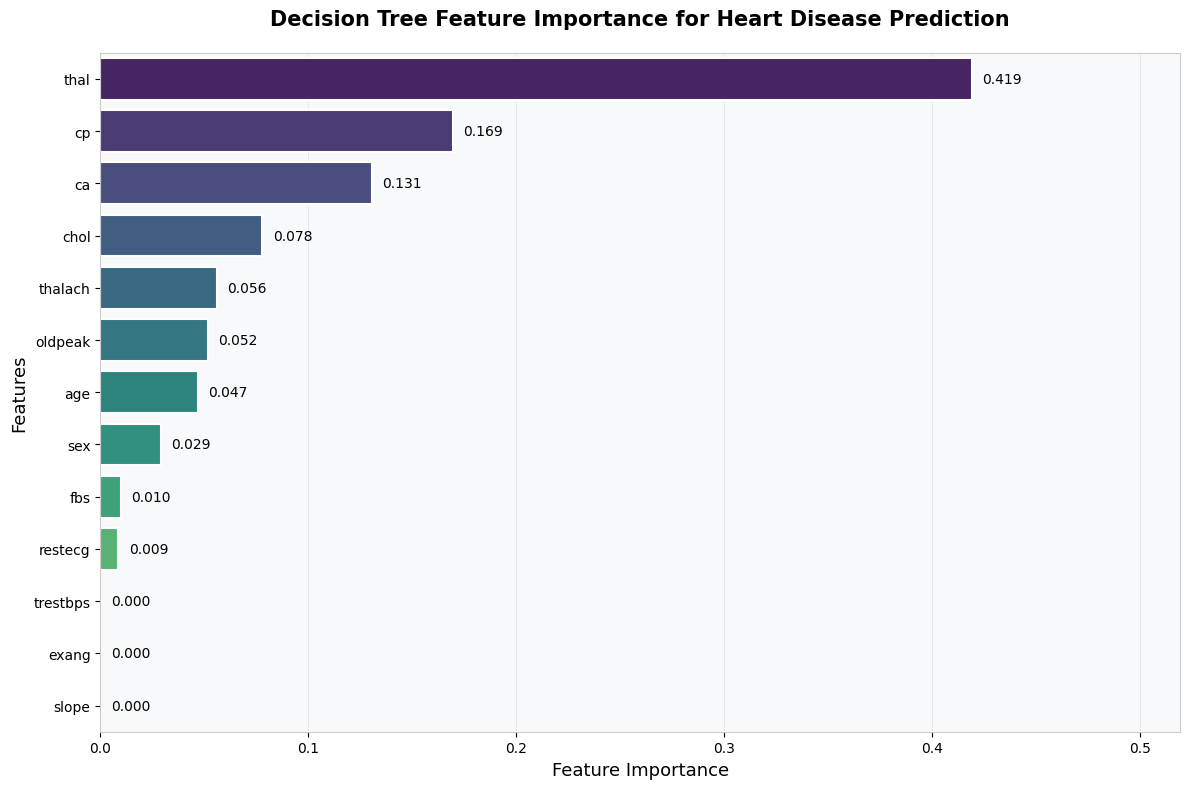

In [90]:
feature_importance = pd.DataFrame({
	"Feature": X.columns,
	"Importance": dt.feature_importances_,
}).sort_values("Importance", ascending=False)

# Visualize feature importance with enhanced seaborn styling
fig, ax = plt.subplots(figsize=(12, 8))

# Create a color gradient for the bars
colors = sns.color_palette("viridis", n_colors=len(feature_importance))

# Create the horizontal bar plot
sns.barplot(
	data=feature_importance,
	x="Importance",
	y="Feature",
	palette=colors,
	hue="Feature",
	ax=ax,
	edgecolor="white",
	linewidth=1.5,
)

# Add value labels on the bars
for i, (importance, feature) in enumerate(
	zip(feature_importance["Importance"], feature_importance["Feature"])
):
	ax.text(
		importance + 0.005,  # Position slightly to the right of the bar
		i,
		f"{importance:.3f}",
		va="center",
		ha="left",
		fontsize=10,
		fontweight="500",
	)

# Styling improvements
ax.set_xlabel("Feature Importance", fontsize=13, fontweight="500")
ax.set_ylabel("Features", fontsize=13, fontweight="500")
ax.set_title(
	"Decision Tree Feature Importance for Heart Disease Prediction",
	fontsize=15,
	fontweight="bold",
	pad=20,
)

# Add subtle grid
ax.grid(axis="x", alpha=0.3, linestyle="-", linewidth=0.5)
ax.set_axisbelow(True)

# Set background color
ax.set_facecolor("#f8f9fa")

# Add subtle border
for spine in ax.spines.values():
	spine.set_edgecolor("#cccccc")
	spine.set_linewidth(0.8)

# Adjust x-axis limit to make space for labels
max_importance = feature_importance["Importance"].max()
ax.set_xlim(0, max_importance + 0.1)

plt.tight_layout()
plt.show()

### Why the Ensemble Model Didn't Perform Best

Despite the theoretical advantages of ensemble methods, our results show that the ensemble models (both hard and soft voting) did not outperform the best individual model. Let's analyze the key reasons:

#### 1. **High Error Correlation Between Models**

The error correlation matrix reveals significant overlap in model errors:
- **LR-KNN correlation: 0.622** (high)
- **LR-DT correlation: 0.408** (moderate)
- **DT-KNN correlation: 0.120** (low)

The high correlation between Logistic Regression and KNN means they tend to make similar mistakes, reducing the ensemble's ability to correct errors through diversity.

#### 2. **Limited Model Disagreement**

Models disagreed on only **18 out of 61 test instances (29.5%)**. This limited disagreement means:
- The ensemble often reinforces the same incorrect predictions
- There's insufficient diversity for effective error correction
- The voting mechanism doesn't have enough "different opinions" to leverage

#### 3. **Individual Model Strength**

Logistic Regression alone achieved excellent performance (accuracy ~85%), making it difficult for the ensemble to improve upon:
- **Strong baseline**: LR already captures the primary linear relationships in the data
- **Diminishing returns**: Additional models provide marginal improvements at best
- **Complexity trade-off**: Ensemble adds complexity without proportional performance gains

#### 4. **Dataset Characteristics**

The heart disease dataset may have properties that favor simpler models:
- **Relatively small dataset** (303 samples) - ensembles typically shine with larger datasets
- **Feature relationships** may be predominantly linear, favoring Logistic Regression
- **Signal-to-noise ratio** might be high enough that a single well-tuned model suffices

#### 5. **Voting Strategy Limitations**

- **Hard voting** treats all models equally, ignoring their individual confidence levels
- **Soft voting** assumes probability calibration, which may not hold equally across all models
- **No weighting mechanism** to give more influence to better-performing models

#### 6. **Hyperparameter Optimization Gap**

While we used GridSearchCV for individual models, the ensemble itself wasn't optimized:
- **Fixed model weights**: All models contribute equally regardless of their individual performance
- **No feature selection**: All models use the same feature set
- **No meta-learning**: Unlike stacking, voting doesn't learn optimal combinations

#### Key Takeaway

The ensemble's underperformance illustrates that **diversity is crucial** for ensemble success. When base models are highly correlated or when a single model already captures the dominant patterns in the data, ensemble methods may not provide significant benefits. In such cases, the added complexity of ensembles may not justify their marginal performance gains.

This result emphasizes the importance of **analyzing model complementarity** before implementing ensembles and considering **alternative approaches** like weighted voting or stacking when simple voting fails to improve performance.

### Evaluation Criteria

A complete and rigorous answer demonstrates:

* Correct data pipeline and model training.
* Justified choice of hyperparameters and preprocessing methods.
* Balanced use of metrics (accuracy alone is insufficient).
* Analytical insight into model complementarity and ensemble behaviour.


#### Stretch Extensions

* Replace simple voting with **stacking**, training a meta-learner (e.g. Logistic Regression) on the outputs of the base classifiers.
* Evaluate robustness using **k-fold cross-validation**.
* Implement a simple **weighted voting scheme** assigning higher weight to better-performing models.